In [113]:
import numpy as np
import pandas as pd
import igraph as ig
from  importlib import resources
import vmlab

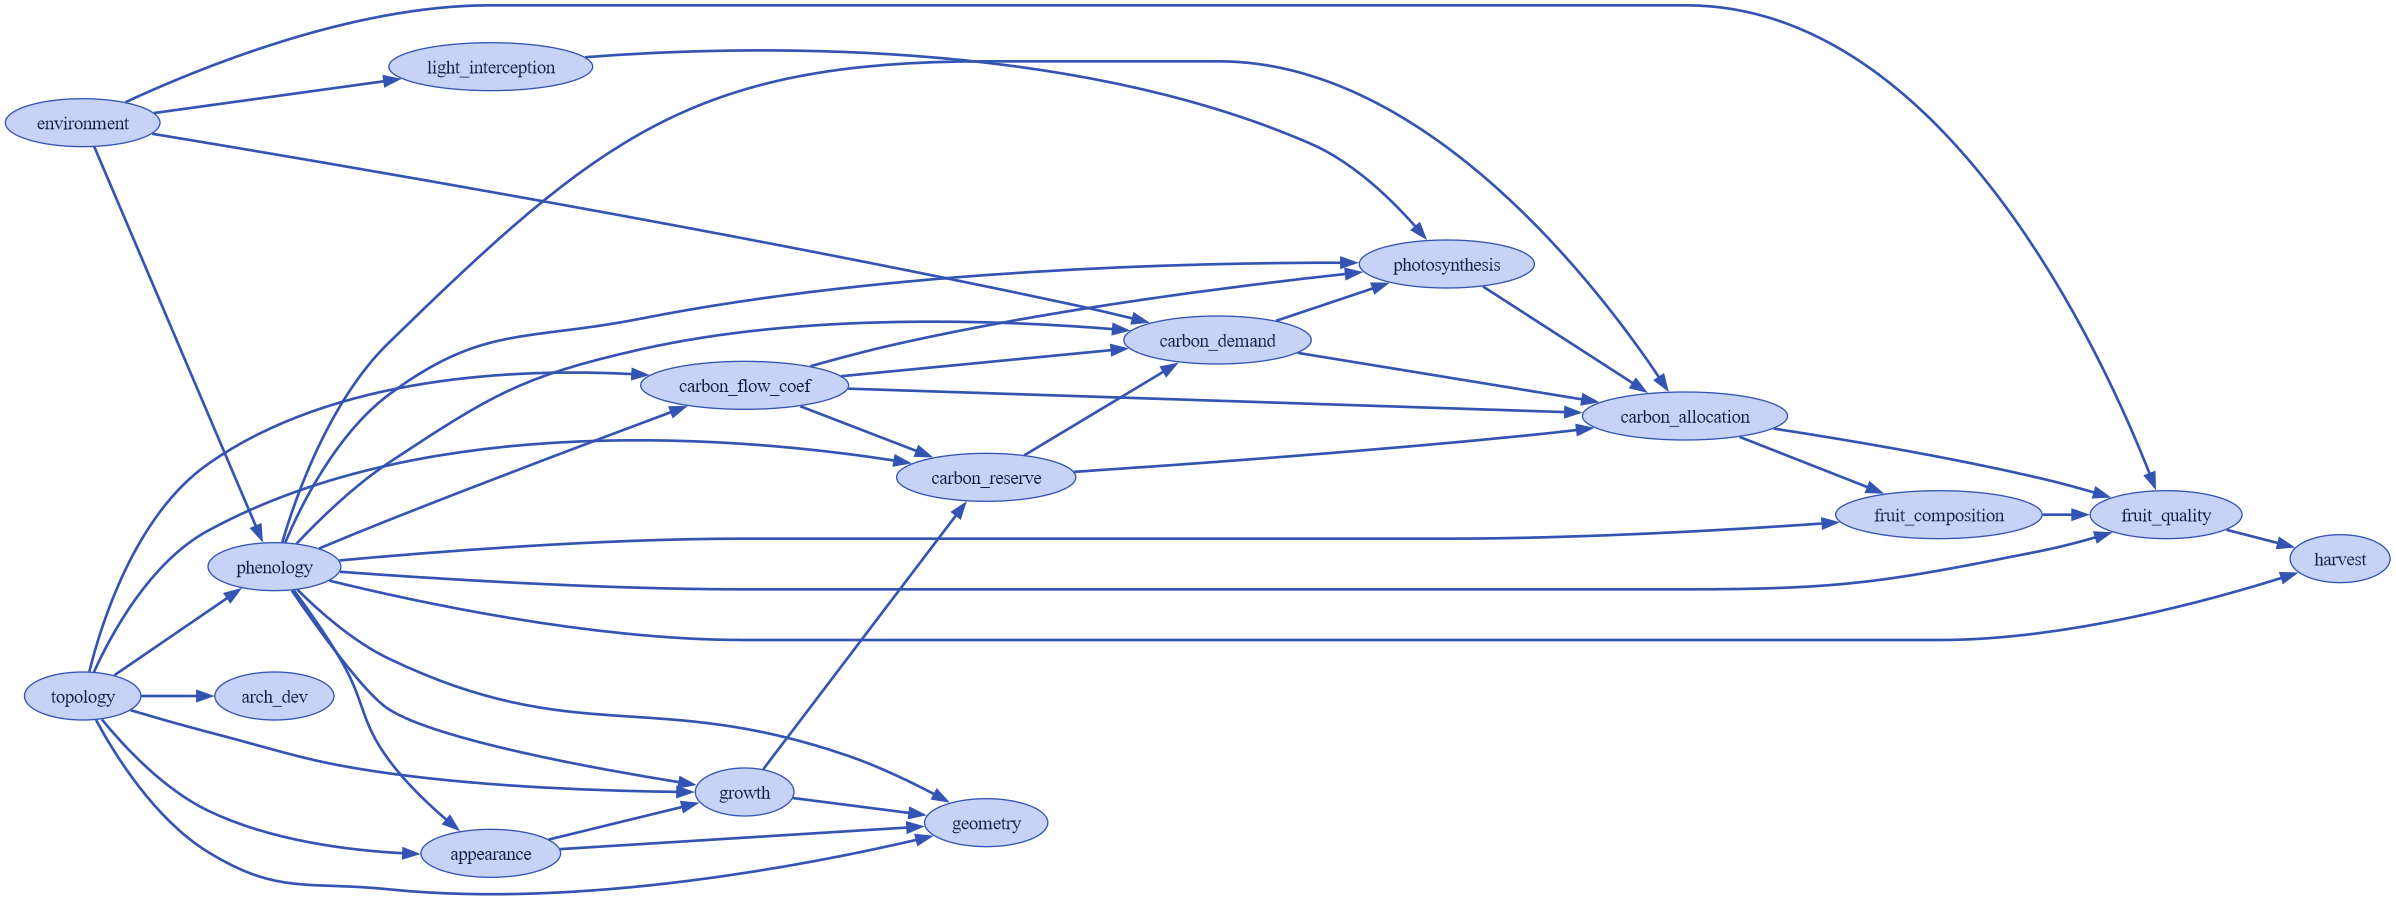

In [114]:
from vmlab.models import fruit_model
from vmlab.processes import harvest
fruit_model = fruit_model.update_processes({'harvest': harvest.HarvestByQuality})
fruit_model.visualize()

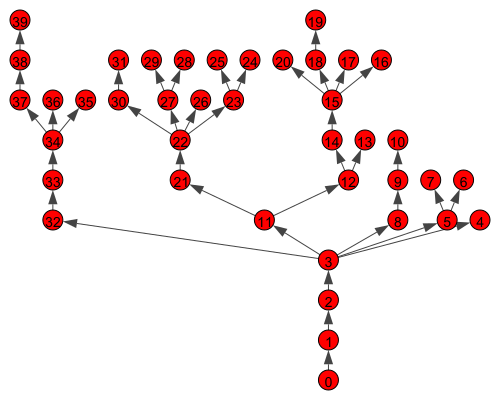

In [115]:
with resources.path('vmlab.data.trees', 'branch_G3.csv') as path:
    tree = pd.read_csv(path)
    graph = vmlab.to_graph(tree)
    vmlab.check_graph(graph)
    layout = graph.layout_reingold_tilford()
    layout.rotate(-180)

ig.plot(graph, bbox=(0,0,500,400), layout=layout, vertex_label=graph.vs.get_attribute_values('id'))

In [118]:
setup = vmlab.create_setup(
    model=fruit_model,
    tree=tree,
    start_date='2002-06-01',
    end_date='2004-06-01',
    setup_toml='fruit_model_branch.toml',
    current_cycle=2,
    input_vars={
        'growth__leaf_senescence_enabled': False,
        'carbon_flow_coef__max_distance_to_fruit': 3,
        'geometry__interpretation_freq': 2
    },
    output_vars={
        'topology': {
            'adjacency': 'day'
        },
        'environment': {
            'TM_day': 'day',
            'RH_day': 'day'
        },
        'carbon_allocation': {
            'DM_fruit': 'day',
            'DM_fleshpeel': 'day',
            'DM_flesh': 'day'
        },
        'carbon_flow_coef': {
            'distances': 'day'
        },
        'harvest': {
            'ripeness_index': 'day',
            'nb_fruit_harvested': None
        },
        'growth': {
            'nb_leaf': None,
        },
        'fruit_quality': {
            'FM_fruit': 'day',
            'W_fleshpeel': 'day',
            'W_flesh': 'day',
            'transpiration_fruit': 'day',
            'osmotic_pressure_fruit': 'day',
            'turgor_pressure_fruit': 'day',
            'water_potential_fruit': 'day',
            'flux_xylem_phloem': 'day',
            'sucrose': 'day'
        }
    }
)

In [119]:
ds_out = vmlab.run(setup, fruit_model, geometry=True)

SceneWidget(scenes=[{'id': 'URypwIJPMQOaVwWsDs9sUOsvM', 'data': b'x\xdaSLrw\xf5\xf7e`Pp\xe0\xe5RPVVd\x00\x020\…

             0% | initialize 

c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\xarray\core\utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


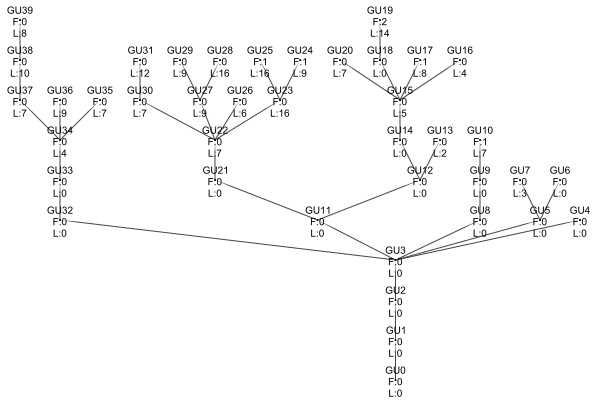

In [24]:
# re-generate graph from the model's adjacency matrix (GU ids and intital tree vertex ids may not be identical)
g = ig.Graph.Adjacency([row.tolist() for row in ds_out.topology__adjacency[-1].data.astype(np.int64)])
layout = g.layout_reingold_tilford()
layout.rotate(-180)
ig.plot(g, layout=layout, bbox=(600, 400),
    vertex_size=1,
    vertex_label_size= 10,
    edge_arrow_width=0.1,
    vertex_label=[
        f'GU{idx}\nF:{int(ds_out.harvest__nb_fruit_harvested.data[idx])}\nL:{int(ds_out.growth__nb_leaf.data[idx])}' for idx in g.vs.indices
    ]
)

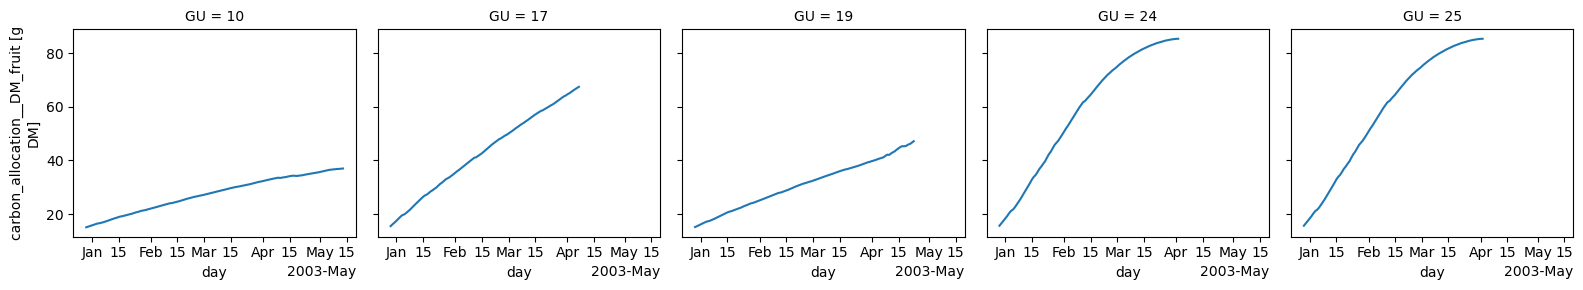

In [25]:
ds_out.carbon_allocation__DM_fruit.where(ds_out.carbon_allocation__DM_fruit > 0, drop=True).plot(col='GU', col_wrap=6)

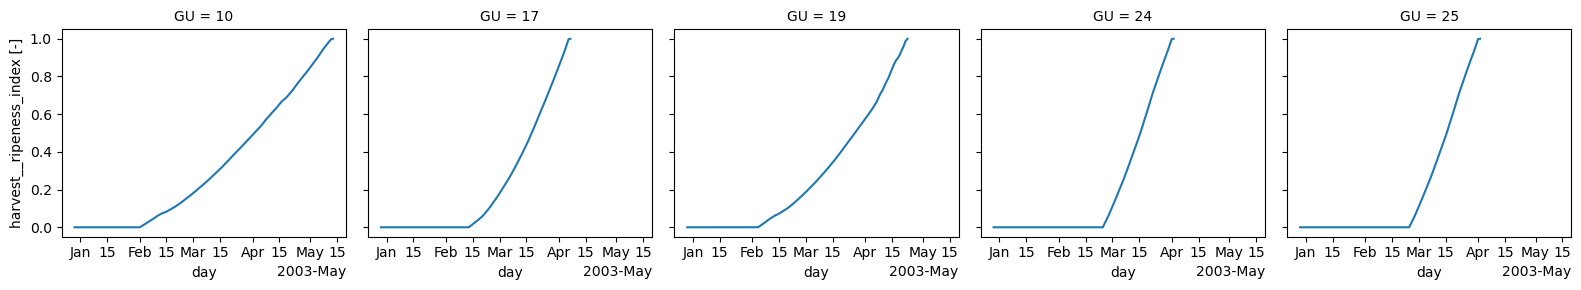

In [26]:
ds_out.harvest__ripeness_index.where(ds_out.carbon_allocation__DM_fruit > 0, drop=True).plot(col='GU', col_wrap=6)

## Visualize carbon flows

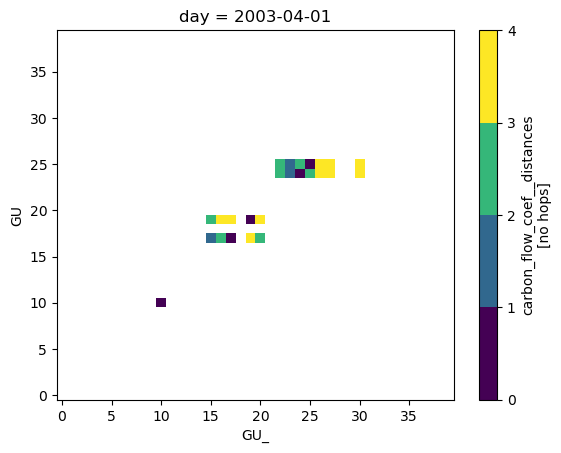

In [27]:
ds_out.carbon_flow_coef__distances.sel({'day': '2003-04-01'}).plot(levels=[0, 1, 2, 3, 4])

In [28]:
# extract coef form a certain date
carbon_flow_coef__distances = ds_out.carbon_flow_coef__distances.sel({'day': '2003-04-01'}).data
edges = np.nonzero(np.isfinite(carbon_flow_coef__distances))

In [29]:
graph_carbon_flow = ig.Graph.Adjacency([row.tolist() for row in ds_out.topology__adjacency[-1].data.astype(np.int64)])
layout2 = graph_carbon_flow.layout_reingold_tilford()
layout2.rotate(-180)

In [30]:
graph_carbon_flow.add_edges(np.flip(np.transpose(edges), axis=1).astype(np.int64), {'distance': carbon_flow_coef__distances[edges]})

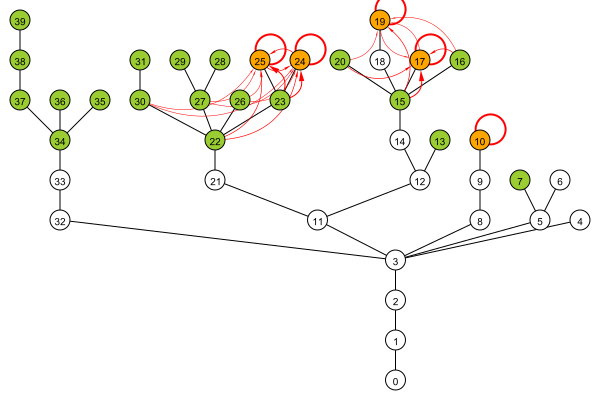

In [32]:
ig.plot(graph_carbon_flow, layout=layout2, bbox=(600, 400), margins=(20,50,20,50),
    vertex_size=20,
    vertex_label_size=10,
    vertex_label=graph.vs.get_attribute_values('id'), # use the original vertex ids (stored as vertex names) from the input dataframe. 
    vertex_color=['orange' if f > 0 else 'YellowGreen' if l > 0 else 'white' for f, l in zip(ds_out.harvest__nb_fruit_harvested.data, ds_out.growth__nb_leaf.data)],
    edge_arrow_width=[1.5/(d+1) if d is not None else 0.1 for d in graph_carbon_flow.es.get_attribute_values('distance')],
    edge_arrow_size=[1.5/(d+1) if d is not None else 0.01 for d in graph_carbon_flow.es.get_attribute_values('distance')],
    edge_color=['red' if d is not None else 'black' for d in graph_carbon_flow.es.get_attribute_values('distance')],
    edge_curved=[0.5 if d is not None else 0 for d in graph_carbon_flow.es.get_attribute_values('distance')],
    edge_width=[2/(d+1) if d is not None else 1 for d in graph_carbon_flow.es.get_attribute_values('distance')]
)

## Prueba de visualizacion de Beizer Curves

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import VBox, HBox, Button, Label, IntSlider, FloatText, Output, Layout, Accordion
from IPython.display import display, clear_output
import os
import io
import re

# --- Configuration ---
# NOTE: Using GEOMETRY_FILE = "geometry_fosil.json" for direct access in the environment
GEOMETRY_FILE = "../vmlab/data/parameters/geometry_fosil.json"
NEW_GEOMETRY_FILE = "quercus_geometry_edited.json"

# --- STRICT NAME LISTS FOR CATEGORIZATION (Normalized to match lowercase, no-separator names) ---

# 1. Names explicitly identified as belonging to the Fruit/Inflorescence Group
FRUIT_EXPLICIT_NAMES = [
    'fruitprofile', 'bractaxis', 'bractsection', 'bractwidth', 'infloaxis', 'bractsectionprofile', 'fruitgrowth'
]

# 2. Names explicitly identified as belonging to the Leaf Group (Core names)
LEAF_CORE_NAMES = [
    'leafsection', 'leafwidthgrowth', 'leafwidth', 'petiolecurve'
]

# --------------------------------------------------------

output_log = Output()
curve_data = {}
point_widgets = []
current_curve_id = None
all_curves = []

# --- New/Updated Curve Extraction and Utility Functions ---

def is_curve(item):
    """Checks if a JSON item is a recognized 2D curve."""
    return item.get('type') in ['BezierCurve2D', 'NurbsCurve2D']

def normalize_name(name):
    """Converts names to a consistent format (lowercase, no separators) for comparison."""
    return name.lower().replace('_', '').replace('-', '')

def extract_all_curves(data):
    """
    Traverses the 'parameters' array to find all geometric curves.
    """
    curves = []
    
    # 1. Check for the correct top-level key: 'parameters'
    parameter_groups = data.get('parameters', [])
    if not parameter_groups:
        with output_log:
            print("WARNING: 'parameters' key not found in JSON data.")
            
    for group in parameter_groups:
        group_name = group.get('name', 'UNKNOWN_GROUP')
        # 2. Iterate through the 'items' in each parameter group
        items = group.get('items', [])
        for item in items:
            if is_curve(item):
                curve_name = item.get('name', 'UNKNOWN_CURVE')
                
                # Store the curve's reference path for saving
                item['__group_name'] = group_name
                item['__curve_path'] = f"{group_name}.{curve_name}"
                
                # Check for control points structure
                ctrl_list = item.get('ctrlPointList')
                if ctrl_list and ctrl_list.get('type') == 'Point3Array' and 'data' in ctrl_list:
                    # Store a reference to the actual control point list in the original JSON object
                    item['ctrl_points_ref'] = ctrl_list['data']
                    curves.append(item)
                else:
                    with output_log:
                        print(f"WARNING: Curve '{curve_name}' in group '{group_name}' is missing 'ctrlPointList' data.")
                        
    return curves

def classify_curve(curve):
    """Classifies a curve based on its normalized name, grouping axis curves with leaf curves."""
    name = normalize_name(curve.get('name', ''))
    
    # Priority 1: Check Fruit/Inflorescence Group
    if name in FRUIT_EXPLICIT_NAMES or 'inflo' in name or 'fruit' in name or 'bract' in name:
        return 'Fruit / Inflorescence'
    
    # Priority 2: Check Leaf Group
    if name in LEAF_CORE_NAMES or 'leaf' in name or 'petiole' in name:
        return 'Leaf'
        
    # Priority 3: Check Axis Curve (General check, often shared)
    if 'axis' in name:
        # AS REQUESTED: Group 'General (Axis/Other)' into 'Leaf' category
        return 'Leaf'
        
    return 'Other' # Keep 'Other' for any truly unclassified curves

def load_geometry_data():
    """Loads JSON data and extracts/classifies all curves."""
    global all_curves, curve_data
    try:
        # Attempt to load the file, handling potential relative path issues
        if not os.path.exists(GEOMETRY_FILE):
            base_file = os.path.basename(GEOMETRY_FILE)
            if os.path.exists(base_file):
                with open(base_file, 'r') as f:
                    data = json.load(f)
            else:
                raise FileNotFoundError(f"File not found at either {GEOMETRY_FILE} or {base_file}")
        else:
            with open(GEOMETRY_FILE, 'r') as f:
                data = json.load(f)
        
        all_curves = extract_all_curves(data)
        
        # Group curves by their classification
        curve_data = {}
        for curve in all_curves:
            category = classify_curve(curve)
            if category not in curve_data:
                curve_data[category] = []
            curve_data[category].append(curve)
            
        with output_log:
            print(f"SUCCESS: Loaded {len(all_curves)} curves from JSON.")
            print(f"Found groups: {list(curve_data.keys())}")
            
        return data # Return the full original data object
            
    except Exception as e:
        with output_log:
            print(f"ERROR loading data: {e}")
        return {}

def save_geometry_json(filepath):
    """Saves the modified geometry data to a new file."""
    global original_geometry_data
    try:
        # The modifications are already made in place within `original_geometry_data`
        with open(filepath, 'w') as f:
            json.dump(original_geometry_data, f, indent=4)
        
        with output_log:
            print(f"INFO: Successfully saved modifications to {filepath}")
            
    except Exception as e:
        with output_log:
            print(f"ERROR saving data: {e}")

# --- Curve Mathematics and Plotting Utilities ---

def create_bezier_points(ctrl_points, num_points=100):
    """Calculates points along a cubic Bezier curve."""
    ctrl_points = np.array(ctrl_points)
    # Check for 4 control points for standard cubic Bezier math
    if ctrl_points.shape[0] != 4:
        # Fallback to just the control polygon points if not cubic Bezier
        return np.array([[cp[0], cp[1]] for cp in ctrl_points])
        
    t = np.linspace(0, 1, num_points)
    # Cubic Bezier formula: P(t) = (1-t)^3*P0 + 3*(1-t)^2*t*P1 + 3*(1-t)*t^2*P2 + t^3*P3
    points = (
        np.outer((1 - t)**3, ctrl_points[0]) +
        np.outer(3 * (1 - t)**2 * t, ctrl_points[1]) +
        np.outer(3 * (1 - t) * t**2, ctrl_points[2]) +
        np.outer(t**3, ctrl_points[3])
    )
    # Return only X and Y coordinates (columns 0 and 1)
    return points[:, :2]

def update_plot(curve_index, curve_list):
    """Updates the Matplotlib plot with the current curve and control points."""
    global current_curve_id
    
    if not curve_list:
        with output_log:
            print("ERROR: No curves to display for this category.")
        return
        
    curve = curve_list[curve_index]
    current_curve_id = curve['id']
    ctrl_points = curve['ctrl_points_ref']
    
    # Calculate the points on the curve
    if curve['type'] == 'BezierCurve2D' and len(ctrl_points) == 4:
        curve_points = create_bezier_points(ctrl_points)
    else:
        # For Nurbs or non-standard Beziers, just show control polygon
        curve_points = create_bezier_points(ctrl_points) # Still use the function to format points
    
    
    with plot_out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # 1. Plot the Curve/Control Polygon
        ax.plot(curve_points[:, 0], curve_points[:, 1], label=f"Curve: {curve['name']}", color='blue', linewidth=2)
        
        # 2. Plot the Control Points (P0, P1, P2, P3)
        ctrl_points_array = np.array(ctrl_points)[:, :2]
        ax.scatter(ctrl_points_array[:, 0], ctrl_points_array[:, 1], color='red', s=50, zorder=5, label='Control Points')
        
        # 3. Plot the Control Polygon (connecting control points)
        ax.plot(ctrl_points_array[:, 0], ctrl_points_array[:, 1], 'r--', alpha=0.5)

        # Annotate points with P0, P1, P2, P3...
        for i, (x, y) in enumerate(ctrl_points_array):
            ax.annotate(f'P{i}', (x, y), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)
            
        ax.set_title(f"Editing Curve: {curve['name']} ({curve['type']})")
        ax.set_xlabel("X-coordinate")
        ax.set_ylabel("Y-coordinate")
        ax.legend()
        ax.grid(True)
        ax.axis('equal') # Ensure the plot maintains aspect ratio
        plt.show()

def update_point_widgets(curve_index, curve_list):
    """Updates the control widgets to match the selected curve's data."""
    global point_widgets, current_curve_id
    
    if not curve_list:
        with output_log:
            print("ERROR: No curves for widget update.")
        return
        
    # Clear existing widgets
    for widget in point_widgets:
        widget.close()
    point_widgets.clear()
    
    # Get the current curve data
    curve = curve_list[curve_index]
    ctrl_points_data_ref = curve['ctrl_points_ref']
    current_curve_id = curve['id']
    
    # Create widgets for each control point
    for i, point in enumerate(ctrl_points_data_ref):
        # We only care about X (index 0) and Y (index 1) for a 2D curve
        x_val = point[0]
        y_val = point[1]
        
        # X Widget
        x_text = FloatText(
            value=x_val,
            description=f'P{i} X:',
            style={'description_width': 'initial'},
            layout=Layout(width='180px')
        )
        
        # Y Widget
        y_text = FloatText(
            value=y_val,
            description=f'P{i} Y:',
            style={'description_width': 'initial'},
            layout=Layout(width='180px')
        )
        
        # --- INTERACTIVITY FIX: Create self-contained handler closure ---
        def create_handler(point_index, coord_index, curve_list_ref, curve_index_ref):
            # Capture the current list and index in the closure for robust plotting
            def handler(change):
                try:
                    # Update the in-memory JSON data directly via the reference
                    curve_list_ref[curve_index_ref]['ctrl_points_ref'][point_index][coord_index] = change.new
                    
                    # Redraw the plot instantly using the captured index and list
                    update_plot(curve_index_ref, curve_list_ref)
                    
                except Exception as e:
                    with output_log:
                        print(f"Error updating point P{point_index} coord {coord_index}: {e}")
            return handler

        # Attach handlers, passing the current index and list reference
        x_text.observe(create_handler(i, 0, curve_list, curve_index), names='value')
        y_text.observe(create_handler(i, 1, curve_list, curve_index), names='value')
        # --- END INTERACTIVITY FIX ---
        
        # Add to the control box
        point_widgets.append(HBox([x_text, y_text], layout=Layout(width='98%')))

    # Display the new widgets
    # --- FIX APPLIED HERE: clear_output must be inside the output context ---
    with point_control_box:
        clear_output(wait=True) # Clears ONLY the point control box content
        display(VBox(point_widgets, layout=Layout(align_items='flex-start')))

# --- Main Setup ---

# Global variables for UI elements
plot_out = Output()
point_control_box = Output()

# 1. Load the data first
original_geometry_data = load_geometry_data()

# Check if data loaded successfully
if not original_geometry_data or not curve_data:
    with output_log:
        print("FATAL ERROR: Could not load geometry data or extract curves. Exiting setup.")
    # Display the error log and stop
    display(VBox([Label("Setup Failed - Check Log Output:"), output_log]))
else:
    # 2. Setup Accordion based on classified groups
    accordion = Accordion()
    titles = []
    children = []
    
    # Sort groups to ensure a consistent order
    sorted_categories = sorted(curve_data.keys())
    
    for category in sorted_categories:
        curve_list = curve_data[category]
        titles.append(f"{category} ({len(curve_list)} curves)")
        
        # Create a dropdown/selector for curves within this category
        curve_names = [curve['name'] for curve in curve_list]
        
        # Use a slider to switch between curves
        curve_selector = IntSlider(
            min=0,
            max=len(curve_list) - 1,
            step=1,
            description=f'Select Curve:',
            readout=True,
            layout=Layout(width='98%')
        )

        def create_accordion_handler(curve_list):
            def handler(change):
                # Update curve index, plot, and point widgets
                update_point_widgets(change.new, curve_list)
                update_plot(change.new, curve_list)
            return handler

        # Initial setting of the slider to show the curve name
        curve_selector.value = 0 # Default to the first curve
        curve_selector.description = f'Select Curve: {curve_names[0]}' if curve_names else 'Select Curve:'
        
        # Observer to handle index change
        curve_selector.observe(create_accordion_handler(curve_list), names='value')

        # Observer to update the description when the value changes
        def update_slider_description(change):
            if change.new < len(curve_names):
                change.owner.description = f'Select Curve: {curve_names[change.new]}'
        
        curve_selector.observe(update_slider_description, names='value')
        
        children.append(VBox([curve_selector]))

    accordion.children = children
    for i, title in enumerate(titles):
        accordion.set_title(i, title)
        
    # 3. Setup Save Button
    save_button = Button(
        description=f"Save ALL Changes to: {NEW_GEOMETRY_FILE}", 
        style={'button_color': '#4CAF50', 'font_weight': 'bold', 'text_color': 'white'},
        layout=Layout(width='98%', margin='15px 0 10px 0')
    )
    save_button.on_click(lambda b: save_geometry_json(NEW_GEOMETRY_FILE))
    
    # 4. Initial plotting for the first sorted group's first curve
    default_category = sorted_categories[0]
    default_curves = curve_data[default_category]
    if default_curves:
        update_point_widgets(0, default_curves)
        update_plot(0, default_curves)
        accordion.selected_index = 0 # Select the first group

    # 5. Assemble the UI layout
    left_panel = VBox([
        Label("1. Select Parameter Group and Curve to Edit:", style={'font_weight': 'bold'}),
        accordion,
        Label("2. Adjust Control Points (P0 is base/axis, P3 is tip):", style={'font_weight': 'bold', 'margin': '10px 0 5px 0'}),
        point_control_box, 
        save_button,
        Label("\nLog Output:", style={'font_weight': 'bold'}),
        output_log
    ], layout=Layout(width='40%', padding='15px', border='1px solid #333', margin='5px', align_items='stretch'))
    
    right_panel = VBox([
        Label("3. Real-time Curve Visualization:", style={'font_weight': 'bold'}),
        plot_out
    ], layout=Layout(width='58%', padding='15px', border='1px solid #333', margin='5px', align_items='stretch'))
    
    display(HBox([left_panel, right_panel], layout=Layout(width='100%', justify_content='space-between')))

# u